<a href="https://colab.research.google.com/github/ThinkingBeyond/BeyondAI-2025/blob/main/Atharva%20Singh%20and%20Mahi%20H%20Shah/DropEdge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>





# Baseline

In [ ]:
pip install torch torch_geometric

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
from torch_geometric.datasets import WebKB
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.data import Data

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

seed_everything(42)

Models

In [ ]:
class GCNNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x  # raw logits

class GraphSAGENet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

Utilities

In [ ]:
def accuracy(pred, y):
    return (pred == y).sum().item() / y.size(0)

def train(model, data, optimizer, device):
    model.train()
    optimizer.zero_grad()
    out = model(data.x.to(device), data.edge_index.to(device))
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask].to(device))
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(model, data, device):
    model.eval()
    out = model(data.x.to(device), data.edge_index.to(device))
    pred = out.argmax(dim=1).cpu()
    y = data.y
    train_acc = accuracy(pred[data.train_mask.cpu()], y[data.train_mask])
    val_acc = accuracy(pred[data.val_mask.cpu()], y[data.val_mask])
    test_acc = accuracy(pred[data.test_mask.cpu()], y[data.test_mask])
    return train_acc, val_acc, test_acc

In [ ]:
def run_experiment(dataset_name='Cornell',
                   model_type='gcn',          # 'gcn' or 'sage'
                   hidden=16,
                   lr=0.01,
                   weight_decay=5e-4,
                   dropout=0.5,
                   epochs=200,
                   device=None,
                   verbose=True):

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    dataset = WebKB(root=f'./data/WebKB/{dataset_name}', name=dataset_name, transform=T.NormalizeFeatures())
    data = dataset[0]

    in_channels = dataset.num_node_features
    out_channels = dataset.num_classes

    if model_type.lower() == 'gcn':
        model = GCNNet(in_channels, hidden, out_channels, dropout=dropout)
    elif model_type.lower() == 'sage':
        model = GraphSAGENet(in_channels, hidden, out_channels, dropout=dropout)
    else:
        raise ValueError("model_type must be 'gcn' or 'sage'")

    model = model.to(device)
    data = data  # keep on CPU; we send tensors to device in forward/eval
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = 0.0
    best_test_at_val = 0.0
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        loss = train(model, data, optimizer, device)
        train_acc, val_acc, test_acc = evaluate(model, data, device)

        if val_acc > best_val:
            best_val = val_acc
            best_test_at_val = test_acc
            best_epoch = epoch

        if verbose and (epoch % 20 == 0 or epoch == 1 or epoch == epochs):
            print(f"[{dataset_name}][{model_type.upper()}] Epoch {epoch:03d} | loss: {loss:.4f} | train: {train_acc:.3f} | val: {val_acc:.3f} | test: {test_acc:.3f}")

    if verbose:
        print(f"-> Best val {best_val:.4f} at epoch {best_epoch}, corresponding test: {best_test_at_val:.4f}")

    return {'dataset': dataset_name, 'model': model_type, 'best_val': best_val, 'test_at_best_val': best_test_at_val, 'best_epoch': best_epoch}


Runs, metrics, plots

Epoch 020 | loss: 1.3428 | val_acc: 0.525 | test_acc: 0.405
Epoch 040 | loss: 1.1928 | val_acc: 0.576 | test_acc: 0.514
Epoch 060 | loss: 1.0210 | val_acc: 0.593 | test_acc: 0.514
Epoch 080 | loss: 0.8266 | val_acc: 0.644 | test_acc: 0.595
Epoch 100 | loss: 0.7208 | val_acc: 0.678 | test_acc: 0.595
Epoch 120 | loss: 0.6467 | val_acc: 0.729 | test_acc: 0.649
Epoch 140 | loss: 0.6609 | val_acc: 0.712 | test_acc: 0.649
Epoch 160 | loss: 0.4929 | val_acc: 0.746 | test_acc: 0.676
Epoch 180 | loss: 0.4946 | val_acc: 0.712 | test_acc: 0.649
Epoch 200 | loss: 0.4805 | val_acc: 0.763 | test_acc: 0.676

==== Final Test Metrics ====
Accuracy: 0.6757
F1-score: 0.4524
AUC: 0.8428


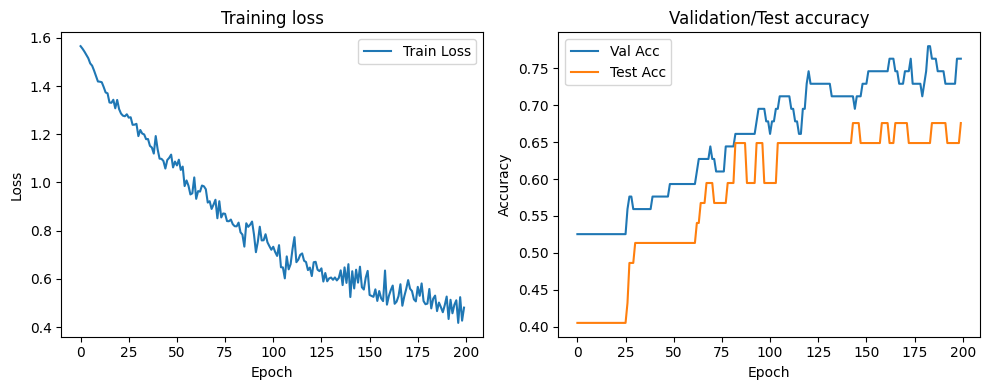

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset_name = 'Cornell'   # 'Cornell', 'Texas', or 'Wisconsin'
model_type = 'sage'          # 'gcn' or 'sage'

dataset = WebKB(root=f'./data/WebKB/{dataset_name}', name=dataset_name, transform=T.NormalizeFeatures())
data = dataset[0]

if data.train_mask.ndim == 2:
    data.train_mask = data.train_mask[:, 0]
    data.val_mask   = data.val_mask[:, 0]
    data.test_mask  = data.test_mask[:, 0]

in_channels = dataset.num_node_features
out_channels = dataset.num_classes
model = GCNNet(in_channels, 16, out_channels) if model_type == 'gcn' else GraphSAGENet(in_channels, 16, out_channels)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

train_losses, val_accs, test_accs = [], [], []
for epoch in range(1, 201):
    loss = train(model, data, optimizer, device)
    train_acc, val_acc, test_acc = evaluate(model, data, device)
    train_losses.append(loss)
    val_accs.append(val_acc)
    test_accs.append(test_acc)
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | loss: {loss:.4f} | val_acc: {val_acc:.3f} | test_acc: {test_acc:.3f}")

model.eval()
out = model(data.x.to(device), data.edge_index.to(device)).cpu()
pred = out.argmax(dim=1)
y_true = data.y.cpu()

acc = accuracy_score(y_true[data.test_mask], pred[data.test_mask])
f1 = f1_score(y_true[data.test_mask], pred[data.test_mask], average='macro')

# AUC (works for multi-class too if available)
try:
    probs = F.softmax(out, dim=1).detach().numpy()
    auc = roc_auc_score(y_true[data.test_mask], probs[data.test_mask], multi_class='ovr')
except Exception:
    auc = None

print("\n==== Final Test Metrics ====")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
if auc:
    print(f"AUC: {auc:.4f}")
else:
    print("AUC: (not applicable for this dataset)")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accs, label='Val Acc')
plt.plot(test_accs, label='Test Acc')
plt.title('Validation/Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


# DropEdge implementation

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.datasets import WebKB
from torch_geometric.transforms import NormalizeFeatures
import random
import numpy as np
import time

Select global configuration here (dataset, no. of layers, model choice)

In [ ]:
# Dataset choice
DATASET_NAME = "Wisconsin"     # "Cornell" or "Texas" or "Wisconsin"

# Model architecture choice
MODEL_TYPE = "GraphSAGE"     # "GraphSAGE" or "GCN"

# Number of layers
NUM_LAYERS = 32         # 2, 4, 8, 16, 32, 64

In [ ]:

dataset = WebKB(root="webkb", name=DATASET_NAME, transform=NormalizeFeatures())
data = dataset[0]

# Fix 10-split masks (as the dtaset came with 10 splits; collapsing it into a single one)
data.train_mask = data.train_mask[:, 0].clone()
data.val_mask   = data.val_mask[:, 0].clone()
data.test_mask  = data.test_mask[:, 0].clone()

print("Final mask shapes:",
      data.train_mask.shape,
      data.val_mask.shape,
      data.test_mask.shape)
print(data)


Final mask shapes: torch.Size([251]) torch.Size([251]) torch.Size([251])
Data(x=[251, 1703], edge_index=[2, 515], y=[251], train_mask=[251], val_mask=[251], test_mask=[251])


In [ ]:
def drop_edge(edge_index, drop_rate):

    if drop_rate == 0:
        return edge_index  # no dropping needed

    E = edge_index.size(1)
    keep = int(E * (1 - drop_rate))

    # random permutation of edges
    perm = torch.randperm(E)[:keep]

    return edge_index[:, perm]

Choose dataset here

Generalised GCN (n-layers)

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers, dropout):

        super().__init__()
        self.dropout = dropout

        # First layer
        self.layers = torch.nn.ModuleList()
        self.layers.append(GCNConv(in_dim, hidden_dim))

        # Middle hidden layers
        for _ in range(num_layers - 2):
            self.layers.append(GCNConv(hidden_dim, hidden_dim))

        # Final layer
        self.layers.append(GCNConv(hidden_dim, out_dim))

    def forward(self, x, edge_index):
        for conv in self.layers[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.layers[-1](x, edge_index)
        return x

Generalised GraphSAGE

In [ ]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layers, dropout):
        super().__init__()
        self.dropout = dropout

        # First layer
        self.layers = torch.nn.ModuleList()
        self.layers.append(SAGEConv(in_dim, hidden_dim))

        # Middle layers
        for _ in range(num_layers - 2):
            self.layers.append(SAGEConv(hidden_dim, hidden_dim))

        # Final layer
        self.layers.append(SAGEConv(hidden_dim, out_dim))

    def forward(self, x, edge_index):
        for conv in self.layers[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.layers[-1](x, edge_index)
        return x

Training & evals

In [ ]:
def train(model, data, optimizer, edge_drop_rate):
    model.train()
    optimizer.zero_grad()

    # randomly drop a subset of edges for this training step
    dropped_edge_index = drop_edge(data.edge_index, edge_drop_rate)

    out = model(data.x, dropped_edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(model, data):
    model.eval()
    logits = model(data.x, data.edge_index)
    preds = logits.argmax(dim=1)

    # compute accuracy on each split
    train_acc = (preds[data.train_mask] == data.y[data.train_mask]).float().mean().item()
    val_acc   = (preds[data.val_mask]   == data.y[data.val_mask]).float().mean().item()
    test_acc  = (preds[data.test_mask]  == data.y[data.test_mask]).float().mean().item()

    return train_acc, val_acc, test_acc

In [ ]:
in_dim = dataset.num_node_features
hidden_dim = 64
out_dim = dataset.num_classes
dropout = 0.5
edge_drop_rate = 0.2
lr = 0.005
epochs = 1000

if MODEL_TYPE == "GCN":
    model = GCN(in_dim, hidden_dim, out_dim, NUM_LAYERS, dropout)
else:
    model = GraphSAGE(in_dim, hidden_dim, out_dim, NUM_LAYERS, dropout)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

Training loop


In [ ]:
def ensure_1d_bool_mask(data, col=0):
    for name in ("train_mask", "val_mask", "test_mask"):
        m = getattr(data, name, None)
        if m is None:
            raise RuntimeError(f"data has no attribute {name}")
        if m.dim() == 2:
            m = m[:, col].clone()
        elif m.dim() == 1:
            m = m.clone()
        else:
            raise RuntimeError(f"Unexpected mask dim for {name}: {m.dim()}")
        if m.dtype != torch.bool:
            m = m.to(torch.bool)
        setattr(data, name, m)


#standardising the masks upfront
ensure_1d_bool_mask(data, col=0)

train_mask = data.train_mask
val_mask   = data.val_mask
test_mask  = data.test_mask


def random_edge_dropout(edge_index, drop_rate):
    if drop_rate <= 0:
        return edge_index
    E = edge_index.size(1)
    keep_mask = torch.rand(E, device=edge_index.device) > float(drop_rate)
    return edge_index[:, keep_mask]


def train(model, data, optimizer, edge_drop_rate):
    model.train()
    optimizer.zero_grad()

    edge_index = random_edge_dropout(data.edge_index, edge_drop_rate)

    out = model(data.x, edge_index)
    loss = F.cross_entropy(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    preds = out.argmax(dim=1)

    train_acc = (preds[train_mask] == data.y[train_mask]).float().mean().item()
    val_acc   = (preds[val_mask]   == data.y[val_mask]).float().mean().item()
    test_acc  = (preds[test_mask]  == data.y[test_mask]).float().mean().item()

    return train_acc, val_acc, test_acc


Hyperparams tuning

In [ ]:
def evaluate(model, data, edge_index=None):
    model.eval()
    if edge_index is None:
        edge_index = data.edge_index

    out = model(data.x, edge_index)
    pred = out.argmax(dim=1)

    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
    val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean().item()
    test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean().item()

    return train_acc, val_acc, test_acc

num_classes = int(data.y.max().item()) + 1


def run_model(lr, drop_rate, edge_drop_rate, hidden, num_layers, model_type, epochs=200):

  #build model based  on user-selected architecture (GCN or SAGE)

    if model_type == "GCN":
        model = GCN(
            data.num_features,
            hidden,
            num_classes,
            num_layers=num_layers,
            dropout=drop_rate
        )
    else:
        model = GraphSAGE(
            data.num_features,
            hidden,
            num_classes,
            num_layers=num_layers,
            dropout=drop_rate
        )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_test = 0.0
    best_val  = 0.0
    best_train = 0.0
    best_epoch = 0


    for epoch in range(epochs):

        train(model, data, optimizer, edge_drop_rate)
        train_acc, val_acc, test_acc = evaluate(model, data)

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: test_acc = {test_acc:.4f}")

        #keeping track of the best test accuracy achieved so far
        if test_acc > best_test:
            best_test = test_acc
            best_val  = val_acc
            best_train = train_acc
            best_epoch = epoch

    return {
        "train_acc": best_train,
        "val_acc": best_val,
        "test_acc": best_test,
        "best_epoch": best_epoch,
        "lr": lr,
        "dropout": drop_rate,
        "edge_drop": edge_drop_rate,
        "hidden": hidden
    }



num_trials = 10
results = []

for trial in range(num_trials):

    seed = int(time.time() * 1000) % 2147483647
    torch.manual_seed(seed)
    np.random.seed(seed + 1)
    random.seed(seed + 2)

    print(f"\n=== Trial {trial+1}/{num_trials} (seed {seed}) ===")

    lr = 10 ** np.random.uniform(-4, -1)
    drop_rate = np.random.uniform(0.0, 0.8)
    edge_drop_rate = np.random.uniform(0.0, 0.8)
    hidden = np.random.randint(16, 256)

    result = run_model(
        lr,
        drop_rate,
        edge_drop_rate,
        hidden,
        NUM_LAYERS,
        MODEL_TYPE,
        epochs=200
    )

    results.append(result)


# Final summary
best = max(results, key=lambda x: x["test_acc"])

print("\n===== FINAL RESULTS =====")
print(f"Dataset:        {DATASET_NAME}")
print(f"Model type:     {MODEL_TYPE}")
print(f"Num layers:     {NUM_LAYERS}")
print(f"Trials run:     {num_trials}")
print("------------------------------")
print(f"Best LR:        {best['lr']:.5f}")
print(f"Best Dropout:   {best['dropout']:.3f}")
print(f"Best EdgeDrop:  {best['edge_drop']:.3f}")
print("------------------------------")
print(f"Best Train Acc: {best['train_acc']:.4f}")
print(f"Best Val Acc:   {best['val_acc']:.4f}")
print(f"Best Test Acc:  {best['test_acc']:.4f}")
print(f"Best Epoch:     {best['best_epoch']}")


=== Trial 1/10 (seed 490314410) ===
Epoch 0: test_acc = 0.2353
Epoch 50: test_acc = 0.5294
Epoch 100: test_acc = 0.5294
Epoch 150: test_acc = 0.5098

=== Trial 2/10 (seed 490346202) ===
Epoch 0: test_acc = 0.5294
Epoch 50: test_acc = 0.5294
Epoch 100: test_acc = 0.5294
Epoch 150: test_acc = 0.5294

=== Trial 3/10 (seed 490357925) ===
Epoch 0: test_acc = 0.2353
Epoch 50: test_acc = 0.5294
Epoch 100: test_acc = 0.4314
Epoch 150: test_acc = 0.5294

=== Trial 4/10 (seed 490406807) ===
Epoch 0: test_acc = 0.2353
Epoch 50: test_acc = 0.5294
Epoch 100: test_acc = 0.5294
Epoch 150: test_acc = 0.5294

=== Trial 5/10 (seed 490440684) ===
Epoch 0: test_acc = 0.2353
Epoch 50: test_acc = 0.4510
Epoch 100: test_acc = 0.5098
Epoch 150: test_acc = 0.5098

=== Trial 6/10 (seed 490502046) ===
Epoch 0: test_acc = 0.2353
Epoch 50: test_acc = 0.2353
Epoch 100: test_acc = 0.5294
Epoch 150: test_acc = 0.5294

=== Trial 7/10 (seed 490512637) ===
Epoch 0: test_acc = 0.5294
Epoch 50: test_acc = 0.5294
Epoch 10